In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

In [198]:
def show_correlation(df: pd.DataFrame, target_feature: str, feature: str, no_std=False):
    
    fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
    # Draw error bars (Matplotlib)
    if no_std == False:
        plt.errorbar(
            df[target_feature],
            df[feature],
            yerr=df[feature + '_std_dev'],
            fmt='o',
            markerfacecolor='steelblue',
            markeredgecolor='black',
            ecolor=(0.5, 0.5, 0.5, 0.3),
            elinewidth=1,
            alpha=0.8,
            capsize=3,
            label='Mean ± SD'
            )

        # draw points and regression plot
        sns.regplot(
            data=df,
            x=target_feature,
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.8, 'color': 'steelblue', 'edgecolor': 'black'},
            line_kws={"color": "red", 'alpha': 0.8},
            )

    else:
        # draw points and regression plot
        sns.regplot(
            data=df,
            x=target_feature,
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.8, 'color': 'steelblue', 'edgecolor': 'black', 'zorder': 3},
            line_kws={"color": "red", 'alpha': 0.8},
            )



    # Compute correlation
    r, p = pearsonr(df[target_feature], df[feature])
    r, p = np.round((r, p), 3)

    ax.set_title(f"r={r}, p={p}")
    ax.grid(color="lightgrey")

    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
    ax.tick_params(length=0)

    plt.tight_layout()
    plt.show()


In [199]:
def show_correlations(df: pd.DataFrame, target_feature: str, features: list):
    """
    Show regression plots and correlation coefficients between one chosen feature
    and all other numeric features in the dataframe.
    """
    # Select numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove the target feature itself
    n_features = len(features)
    if n_features == 0:
        print("No other numeric columns to correlate with.")
        return

    # --- Determine subplot grid size dynamically ---
    n_cols = n_features
    n_rows = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows), dpi=300)
    axes = axes.flatten()  # flatten for easy iteration

    # --- Loop through all features and plot ---
    for i, feature in enumerate(features):
        ax = axes[i]

        if feature != 'n_frames' and feature != 'n_geese' and 'std_dev' not in feature:
            # Draw error bars (Matplotlib)
            ax.errorbar(
                df[target_feature],
                df[feature],
                yerr=df[feature + '_std_dev'],
                fmt='o',
                markerfacecolor='steelblue',
                markeredgecolor='black',
                ecolor=(0.5, 0.5, 0.5, 0.3),
                elinewidth=1,
                alpha=0.8,
                capsize=3,
                label='Mean ± SD'
                )

        # draw points and regression plot
        sns.regplot(
            data=df,
            x=target_feature,
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.8, 'color': 'steelblue', 'edgecolor': 'black', 'zorder': 3},
            line_kws={"color": "red", 'alpha': 0.8},
        )

        # Compute correlation
        r, p = pearsonr(df[target_feature], df[feature])
        r, p = np.round((r, p), 3)

        ax.set_title(f"{feature} vs {target_feature}\n(r={r}, p={p})")
        ax.grid(color="lightgrey")

        ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
        ax.tick_params(length=0)

    # Hide empty subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [200]:
features = [
    'n_frames',
    "normalized_velocity_alignment",
    "velocity_deviation",
    "first_pca_component",
    "first_pca_component_velocity_alignment",
    "second_pca_component",
    "second_pca_component_velocity_alignment",
    "gaussian_entropy",
]

In [201]:
df = pd.read_csv('data/metric_means.csv', index_col=0)
df = df.drop(columns=['crosswind_speed'])
df = df.dropna()

In [202]:
print(f'Dropping {len(df[df['n_frames'] <= 180])} data_points out of {len(df)}')
df = df[df['n_frames'] > 180]

Dropping 4 data_points out of 164


In [203]:
print(f'Dropping {len(df[df['gaussian_entropy'] <= -7])} data points out of {len(df)}')
df = df[df['gaussian_entropy'] > -7]
df['exp_gaussian_entropy'] = np.exp(df['gaussian_entropy'])

Dropping 4 data points out of 160


In [204]:
print(f'Dropping {len(df[df['first_pca_component'] >= 4])} data_points out of {len(df)}')
df = df[df['first_pca_component'] < 4]
df.describe()

Dropping 9 data_points out of 156


,n_geese,n_frames,normalized_velocity_alignment,velocity_deviation,first_pca_component,second_pca_component,gaussian_entropy,normalized_velocity_alignment_std_dev,velocity_deviation_std_dev,first_pca_component_std_dev,second_pca_component_std_dev,gaussian_entropy_std_dev,exp_gaussian_entropy
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,24.122449,520.360544,0.998139,0.877929,0.887722,0.697976,0.534950,0.001109,0.245760,0.556301,0.222529,0.757815,5.545277
std,15.394314,131.395562,0.001825,0.426904,0.761986,0.151001,1.851994,0.001119,0.162691,0.560883,0.087073,0.616911,8.096132
min,4.000000,235.000000,0.989044,0.152738,0.022424,0.227773,-4.724652,0.000026,0.034203,0.014034,0.012275,0.183169,0.008874
25%,13.000000,434.500000,0.997391,0.476890,0.253790,0.597660,-0.916580,0.000264,0.131814,0.144665,0.159622,0.441896,0.400078
50%,21.000000,510.000000,0.998606,0.892094,0.734510,0.701716,0.789148,0.000766,0.219649,0.413307,0.245490,0.606065,2.201519
75%,33.000000,614.000000,0.999533,1.204002,1.282154,0.810847,1.999922,0.001532,0.311486,0.747848,0.274295,0.766129,7.388746
max,70.000000,962.000000,0.999961,2.069859,3.779254,0.982953,3.912447,0.006510,0.916545,3.656881,0.373913,3.676696,50.021205


In [205]:
wind_df = pd.read_csv('data/metric_means.csv', index_col=0)
print(f"{wind_df.isna().sum().sum()} out of {len(wind_df)} data points are nans")
wind_df = wind_df.dropna()
wind_df['crosswind_speed'] = np.abs(wind_df['crosswind_speed'])

17 out of 164 data points are nans


In [206]:
print(f'Dropping {len(wind_df[wind_df['n_frames'] <= 180])} data_points out of {len(wind_df)}')
wind_df = wind_df[wind_df['n_frames'] > 180]

Dropping 2 data_points out of 147


In [207]:
print(f'Dropping {len(wind_df[wind_df['first_pca_component'] >= 4])} data_points out of {len(wind_df)}')
wind_df = wind_df[wind_df['first_pca_component'] < 4]
wind_df.describe()

Dropping 7 data_points out of 145


,n_geese,n_frames,crosswind_speed,normalized_velocity_alignment,velocity_deviation,first_pca_component,second_pca_component,gaussian_entropy,normalized_velocity_alignment_std_dev,velocity_deviation_std_dev,first_pca_component_std_dev,second_pca_component_std_dev,gaussian_entropy_std_dev
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,22.978261,518.630435,0.537183,0.998149,0.863558,0.883302,0.691034,0.128409,0.001133,0.252258,0.573816,0.226329,0.799117
std,15.020408,129.341684,0.626694,0.001859,0.420387,0.759335,0.152129,2.999272,0.001141,0.169958,0.578657,0.085972,0.664836
min,2.000000,235.000000,0.000000,0.989044,0.152738,0.022424,0.227773,-20.201600,0.000026,0.038841,0.014034,0.012275,0.183169
25%,11.250000,435.500000,0.000000,0.997428,0.469524,0.251391,0.589766,-1.050648,0.000273,0.130639,0.141649,0.165538,0.446762
50%,20.000000,505.500000,0.361158,0.998671,0.832770,0.732082,0.678142,0.683233,0.000769,0.221582,0.415814,0.247029,0.608507
75%,32.000000,613.750000,0.857283,0.999487,1.194951,1.285427,0.803166,1.988932,0.001535,0.321023,0.799619,0.275034,0.779174
max,70.000000,962.000000,2.822452,0.999961,2.069859,3.779254,0.982953,3.912447,0.006510,0.916545,3.656881,0.373913,3.676696


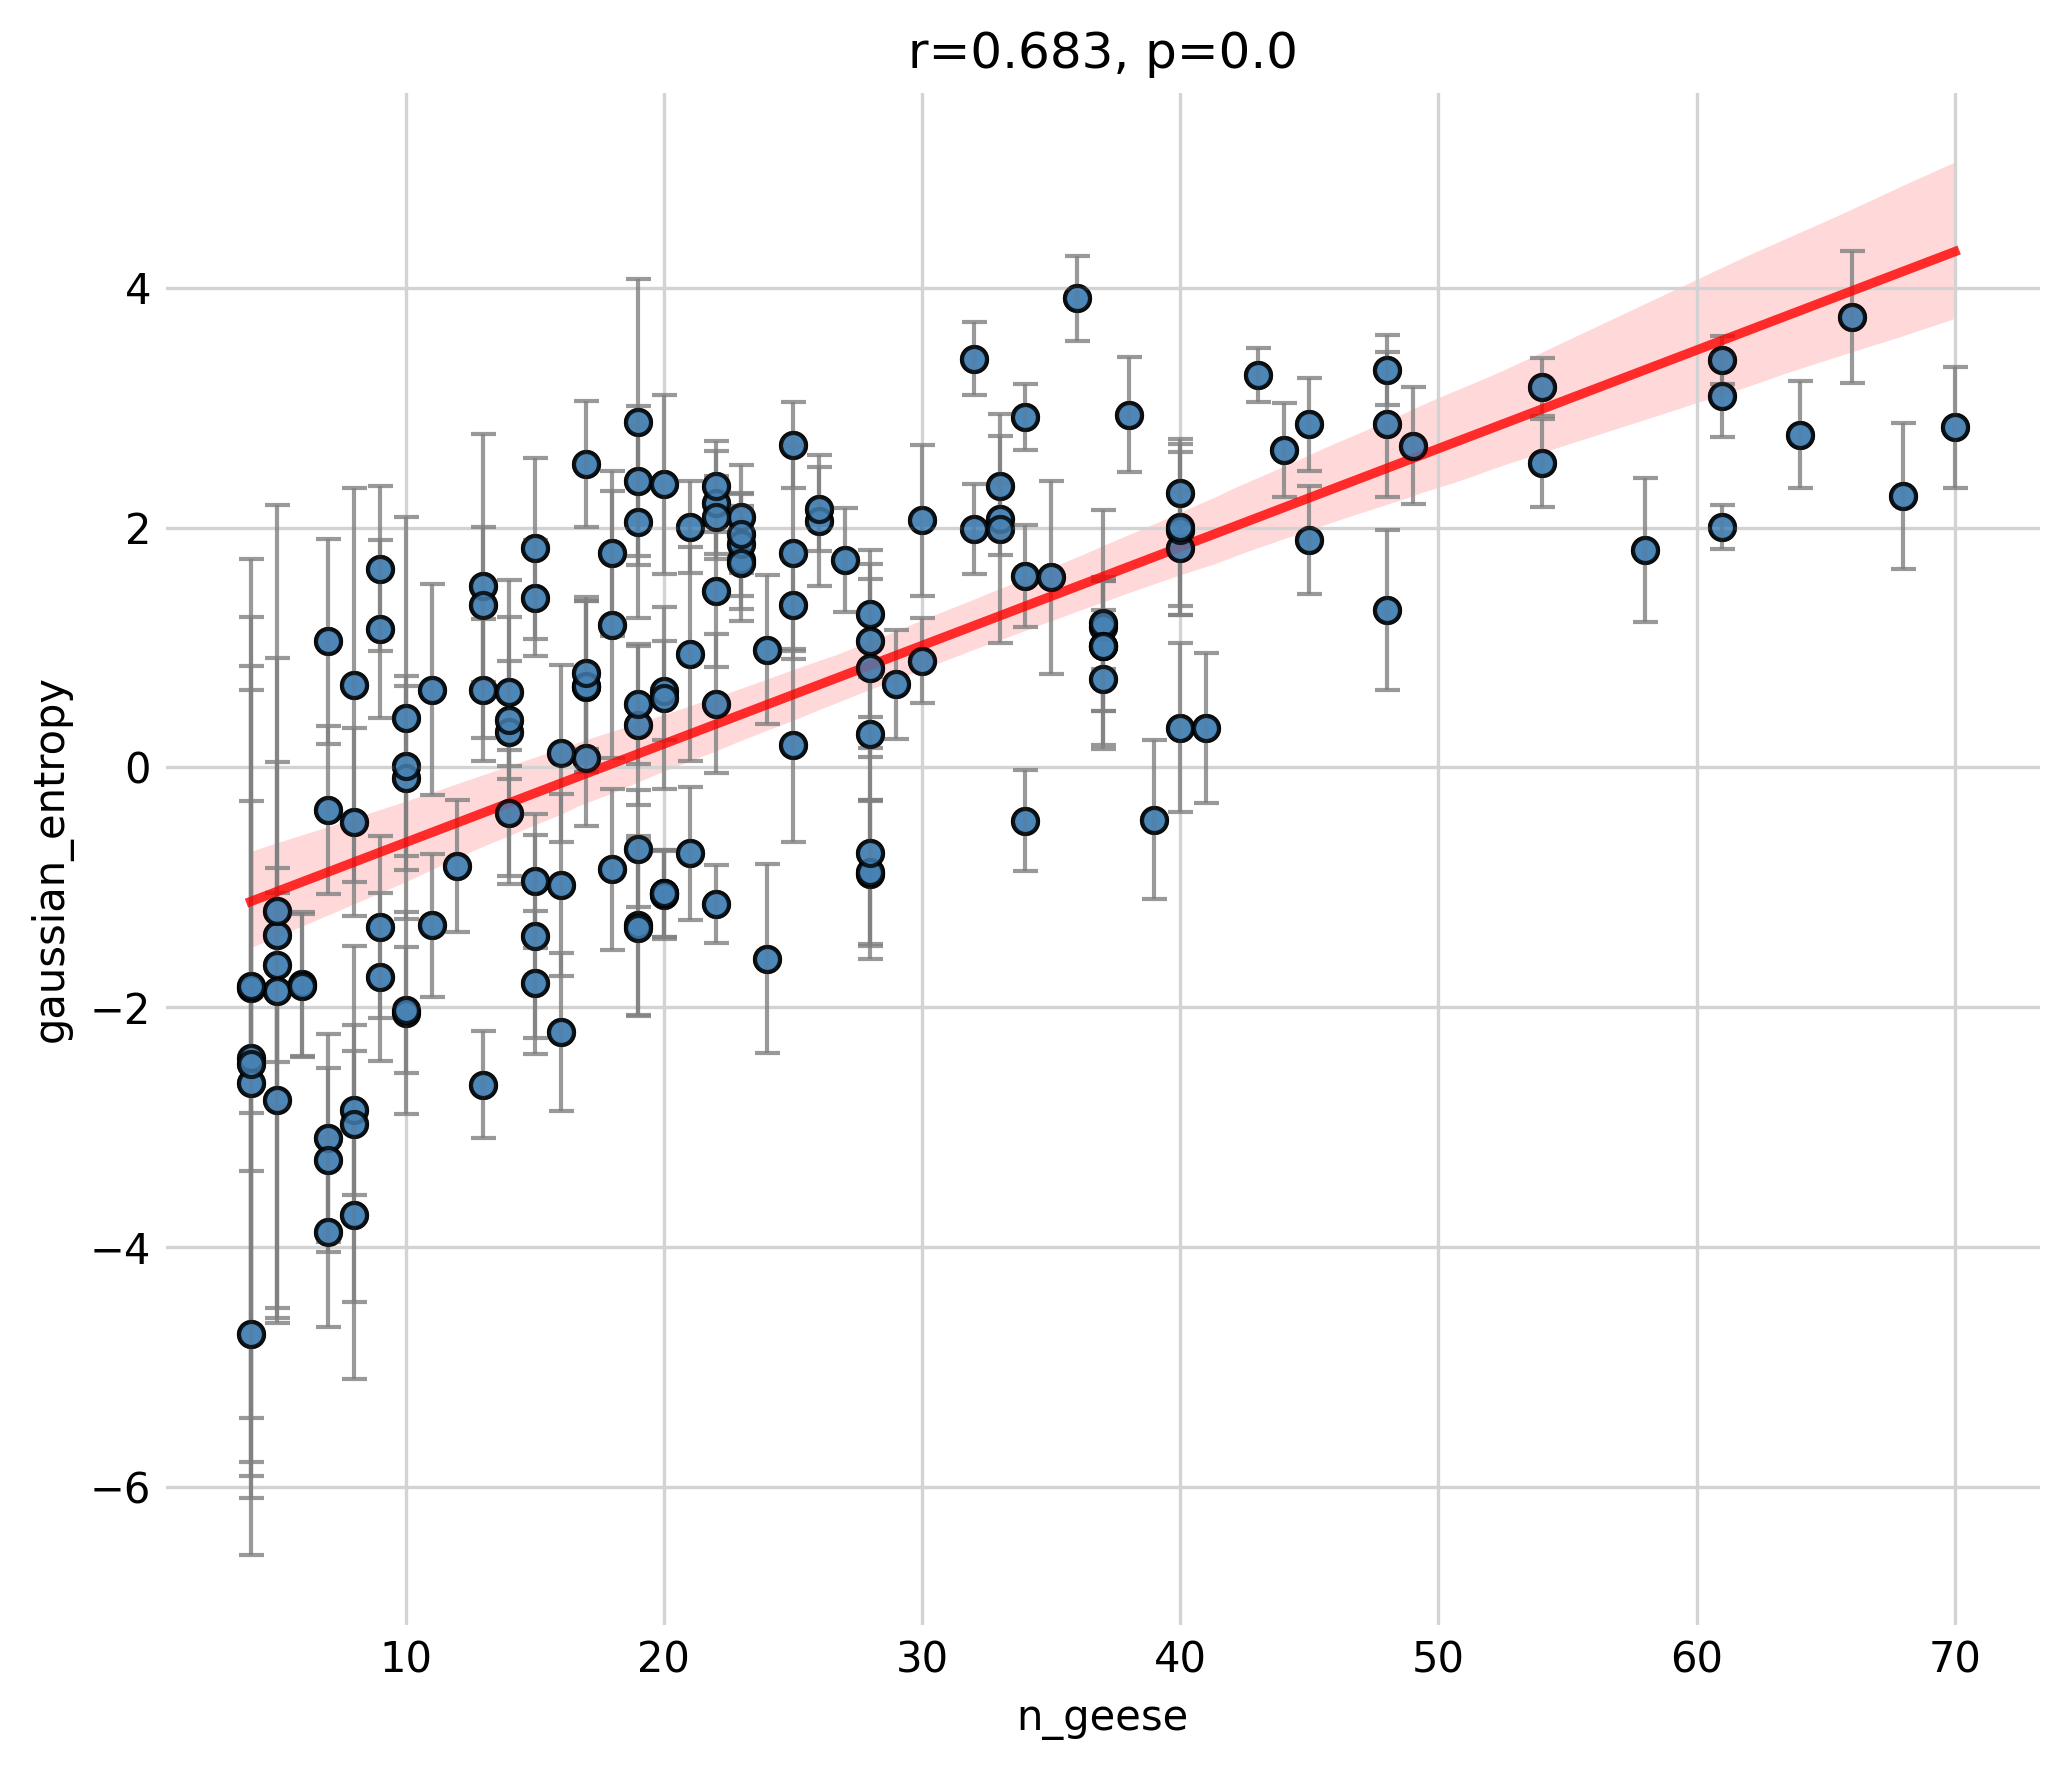

In [208]:
show_correlation(df, 'n_geese', 'gaussian_entropy')

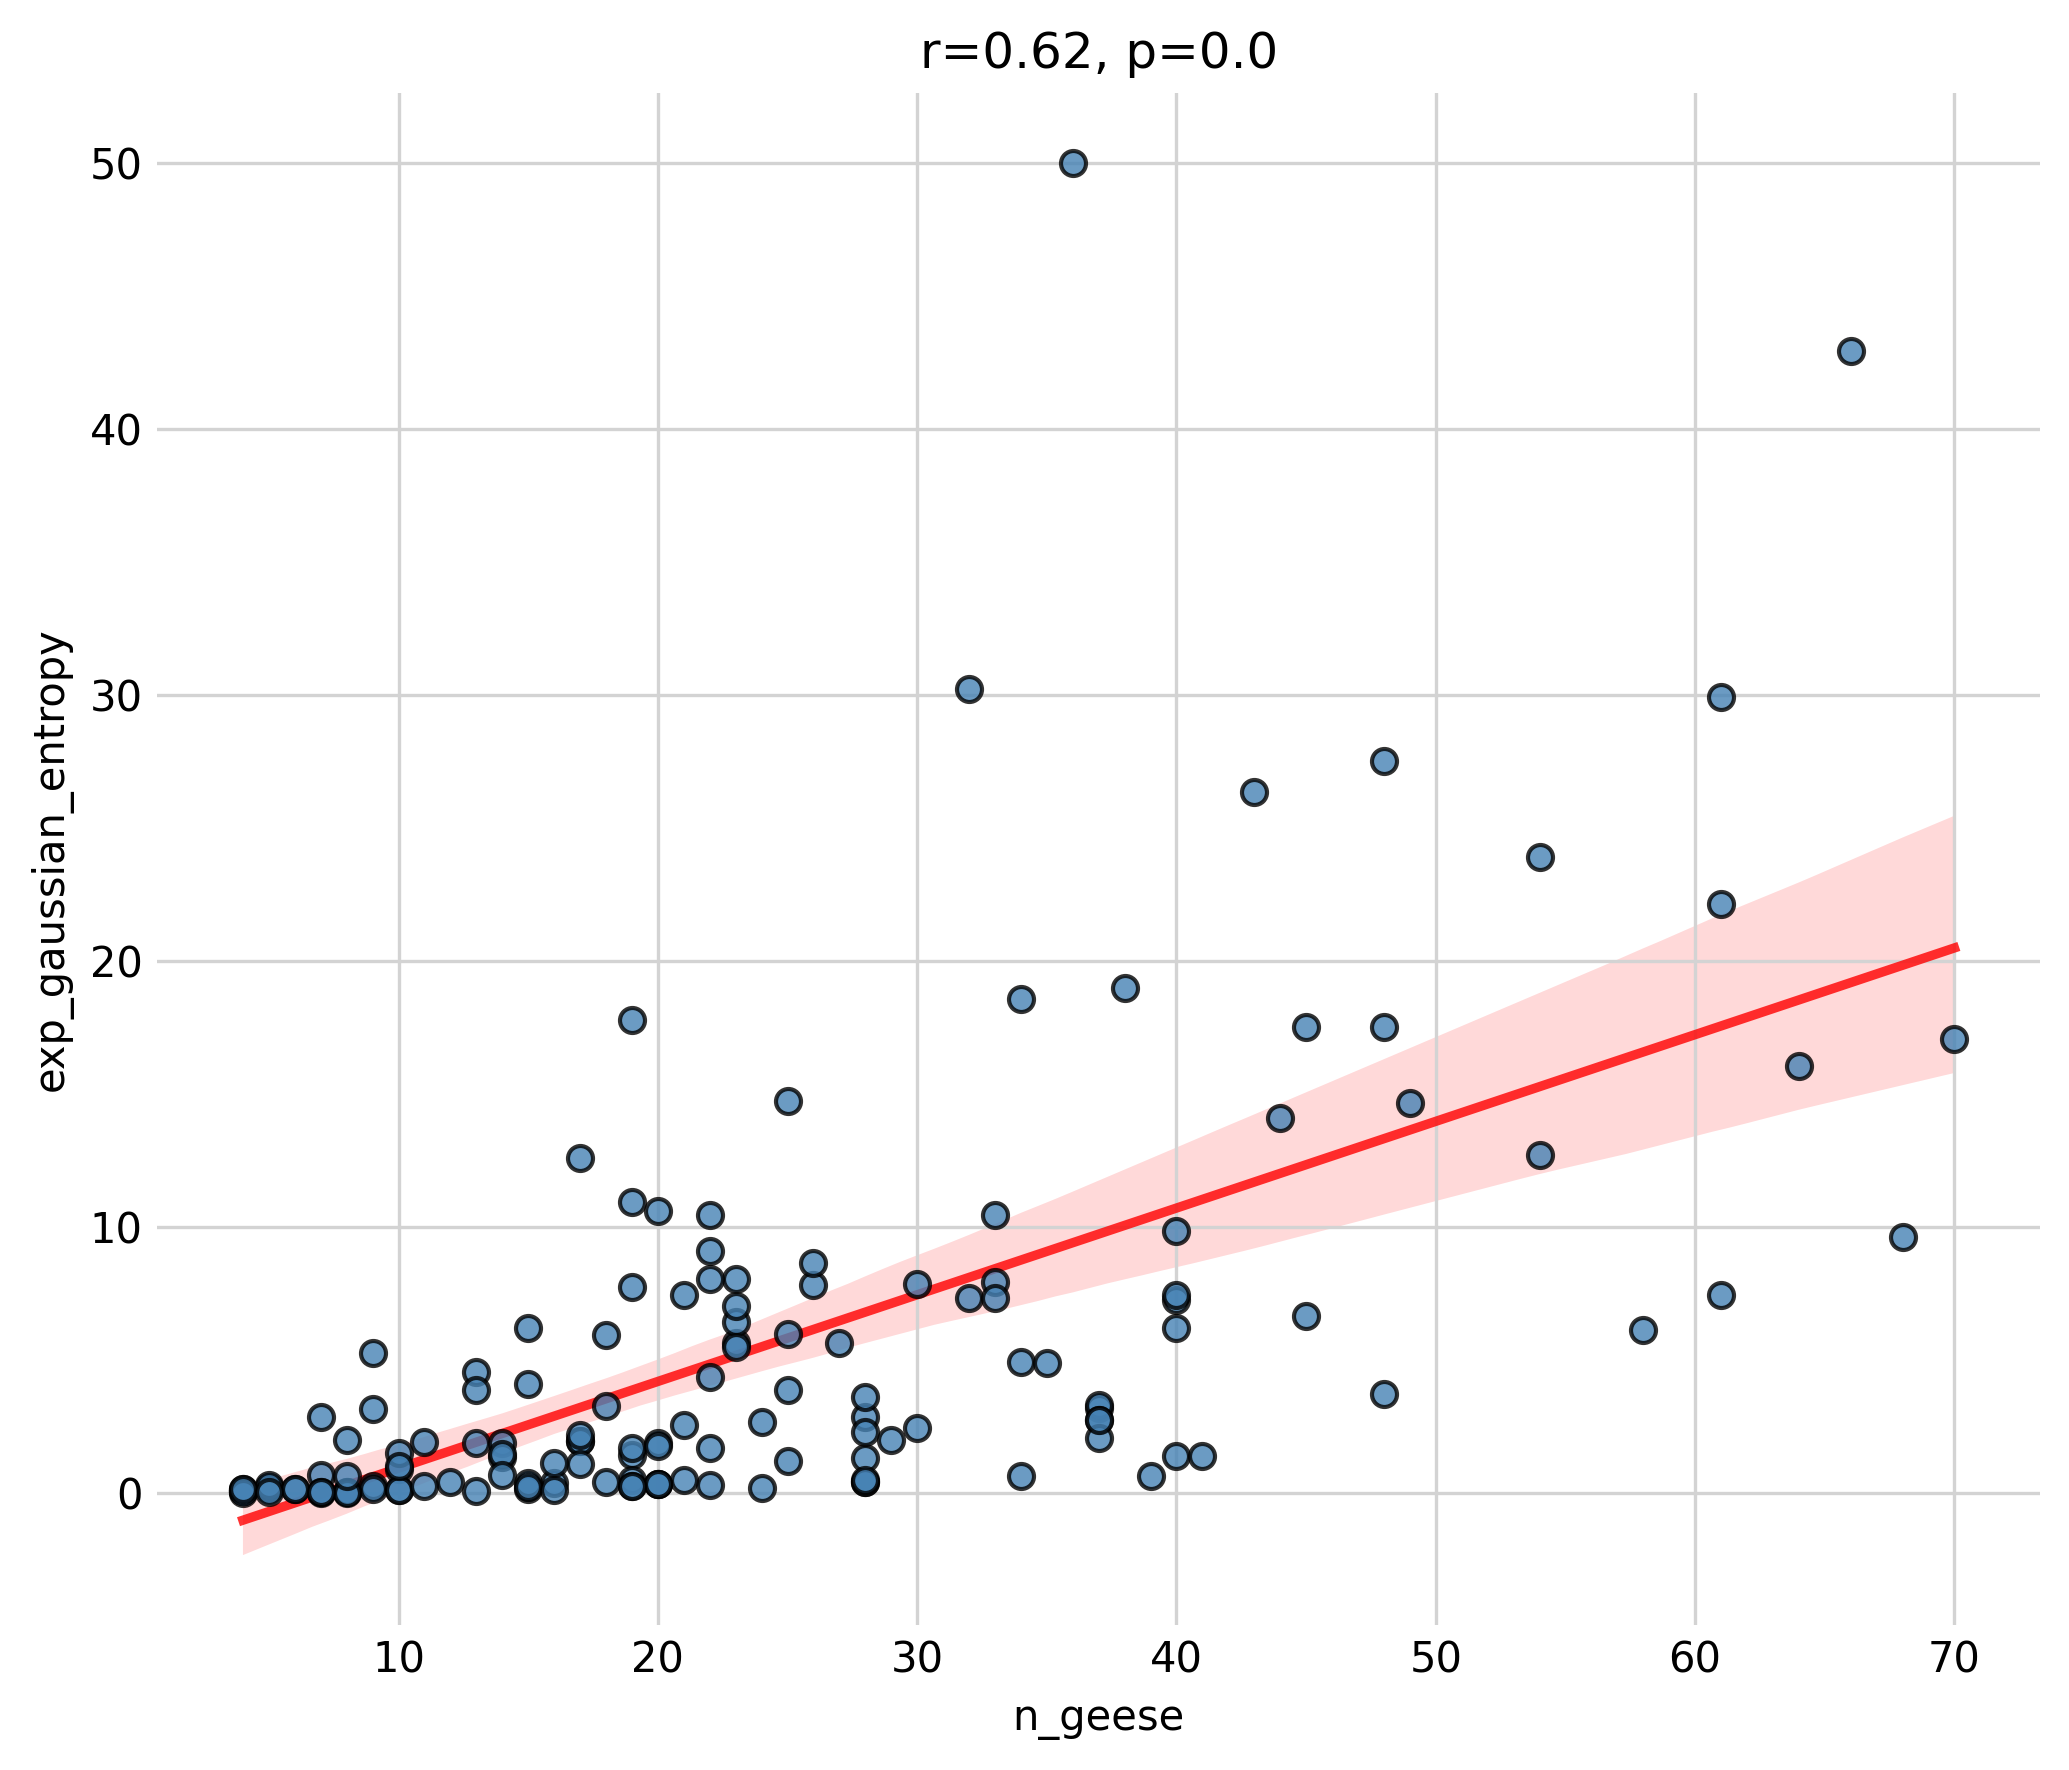

In [209]:
show_correlation(df, 'n_geese', 'exp_gaussian_entropy', no_std=True)

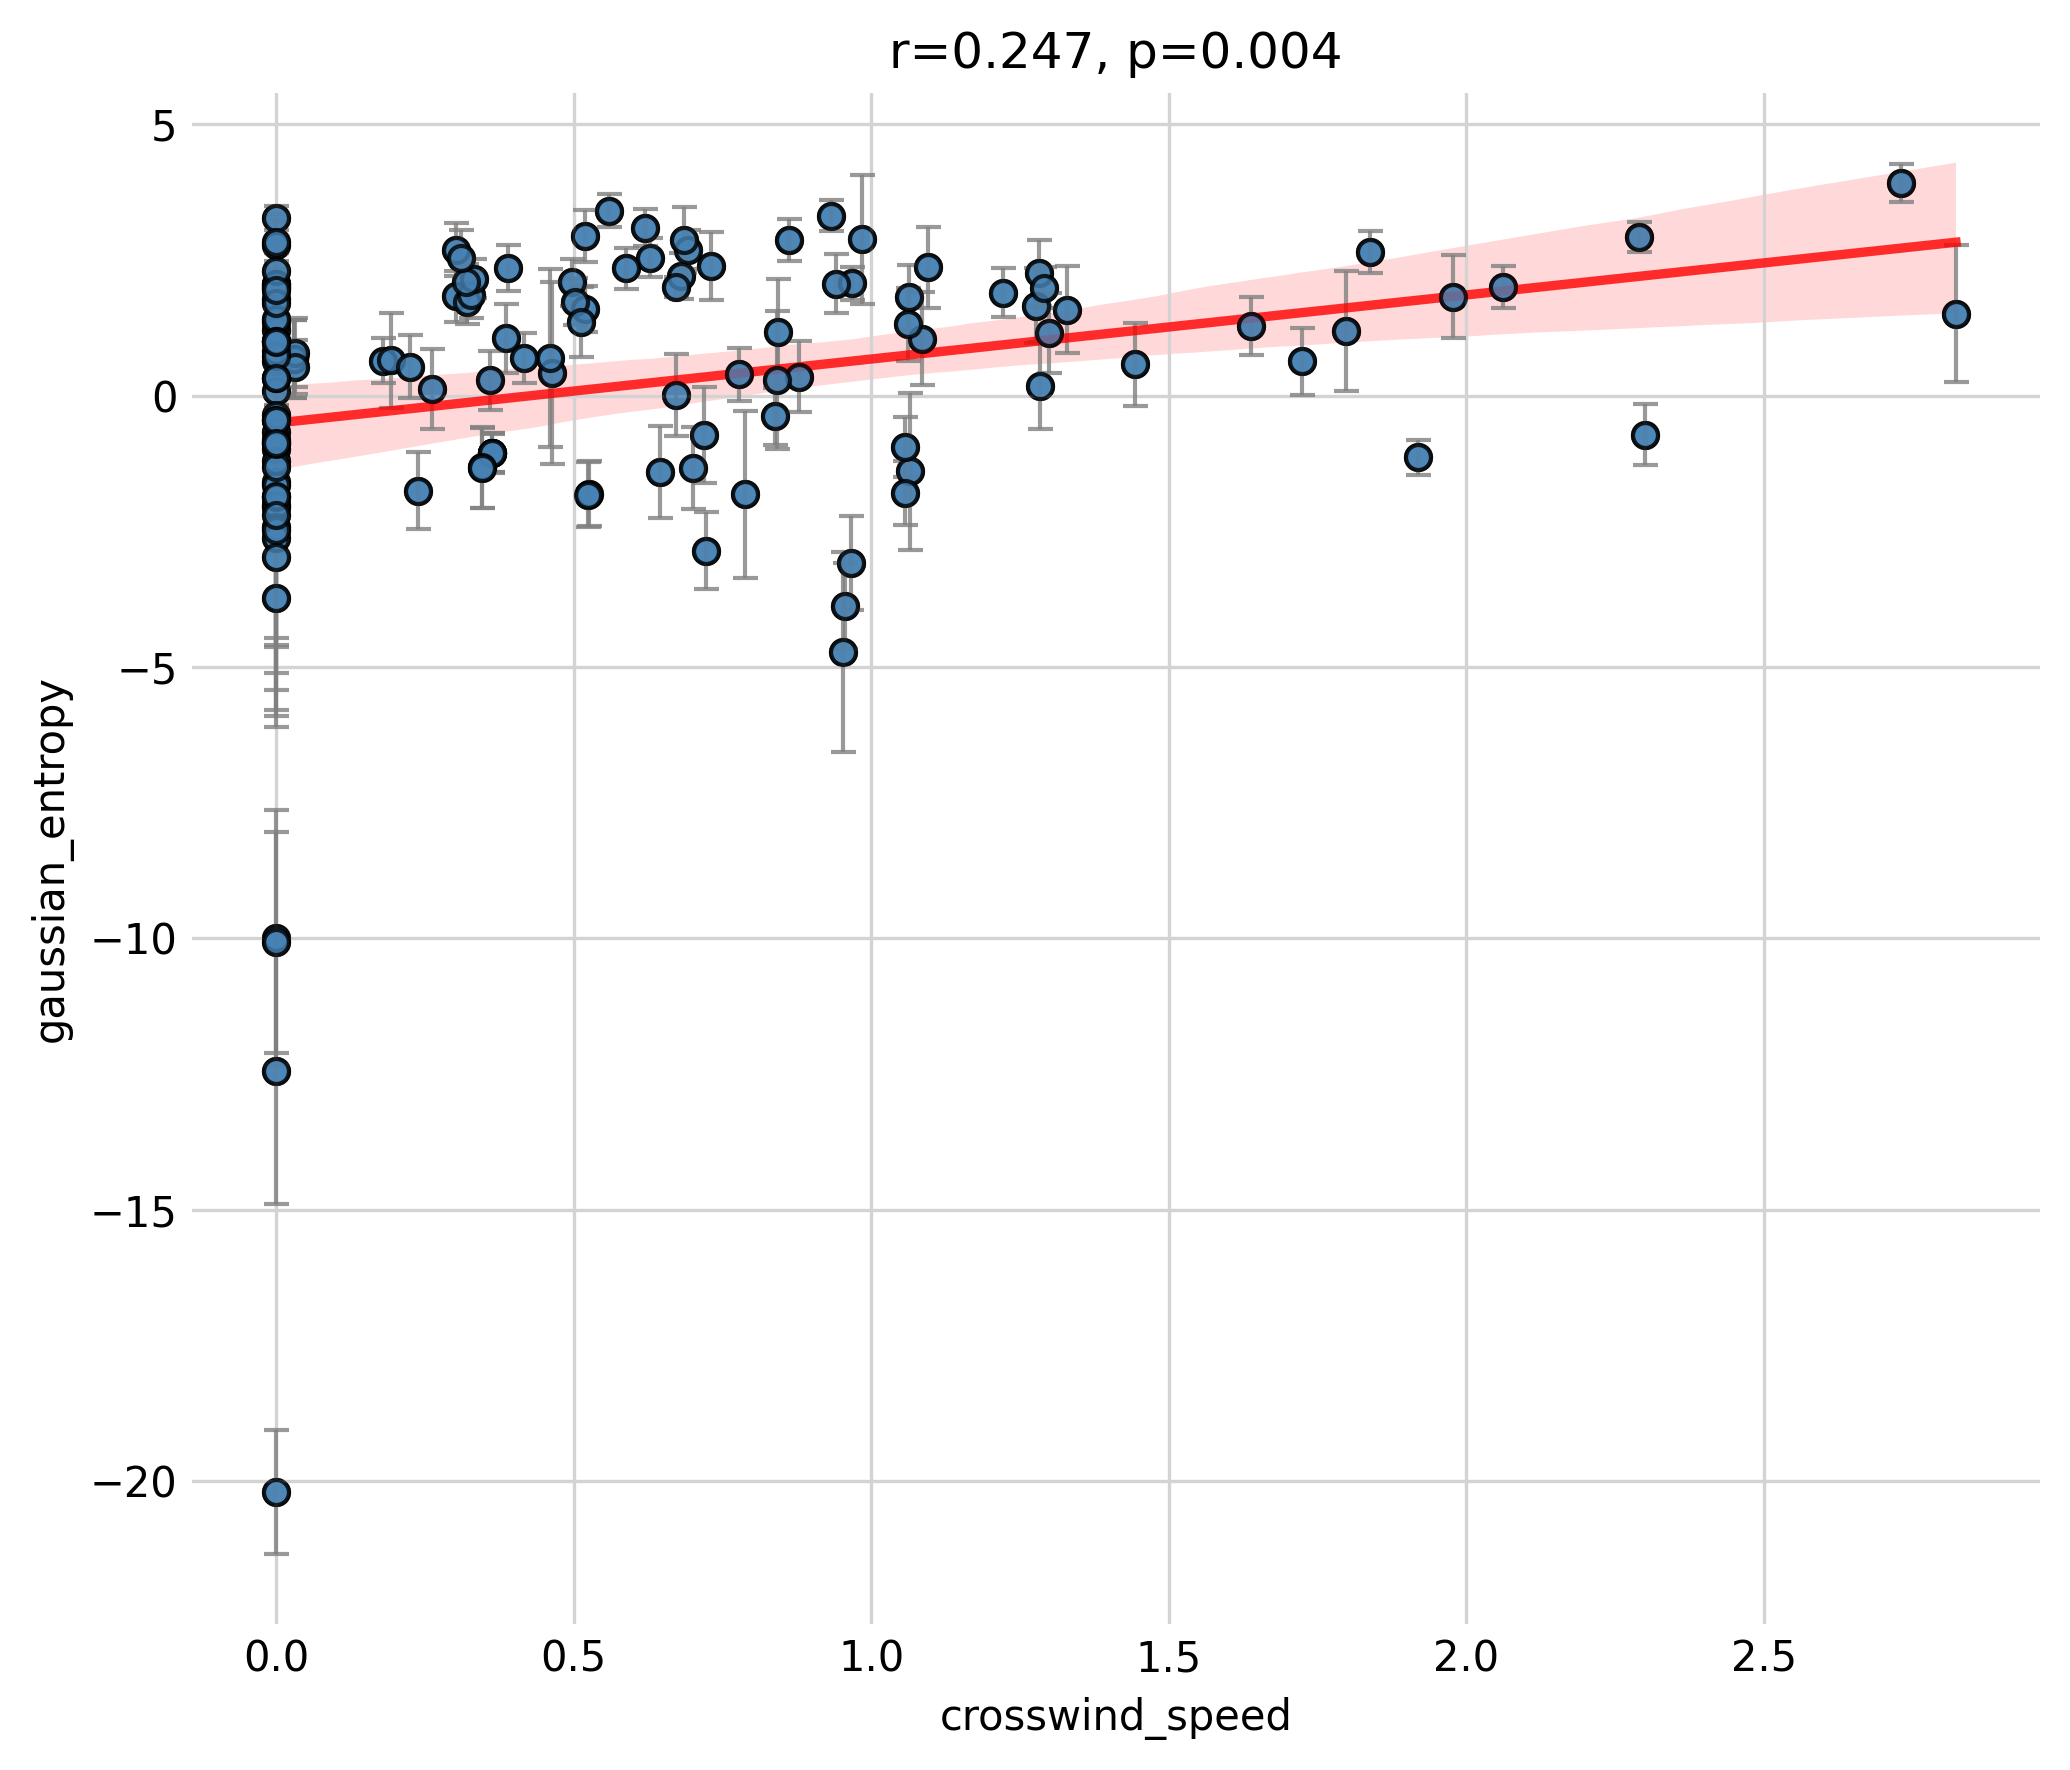

In [210]:
show_correlation(wind_df, 'crosswind_speed', 'gaussian_entropy')

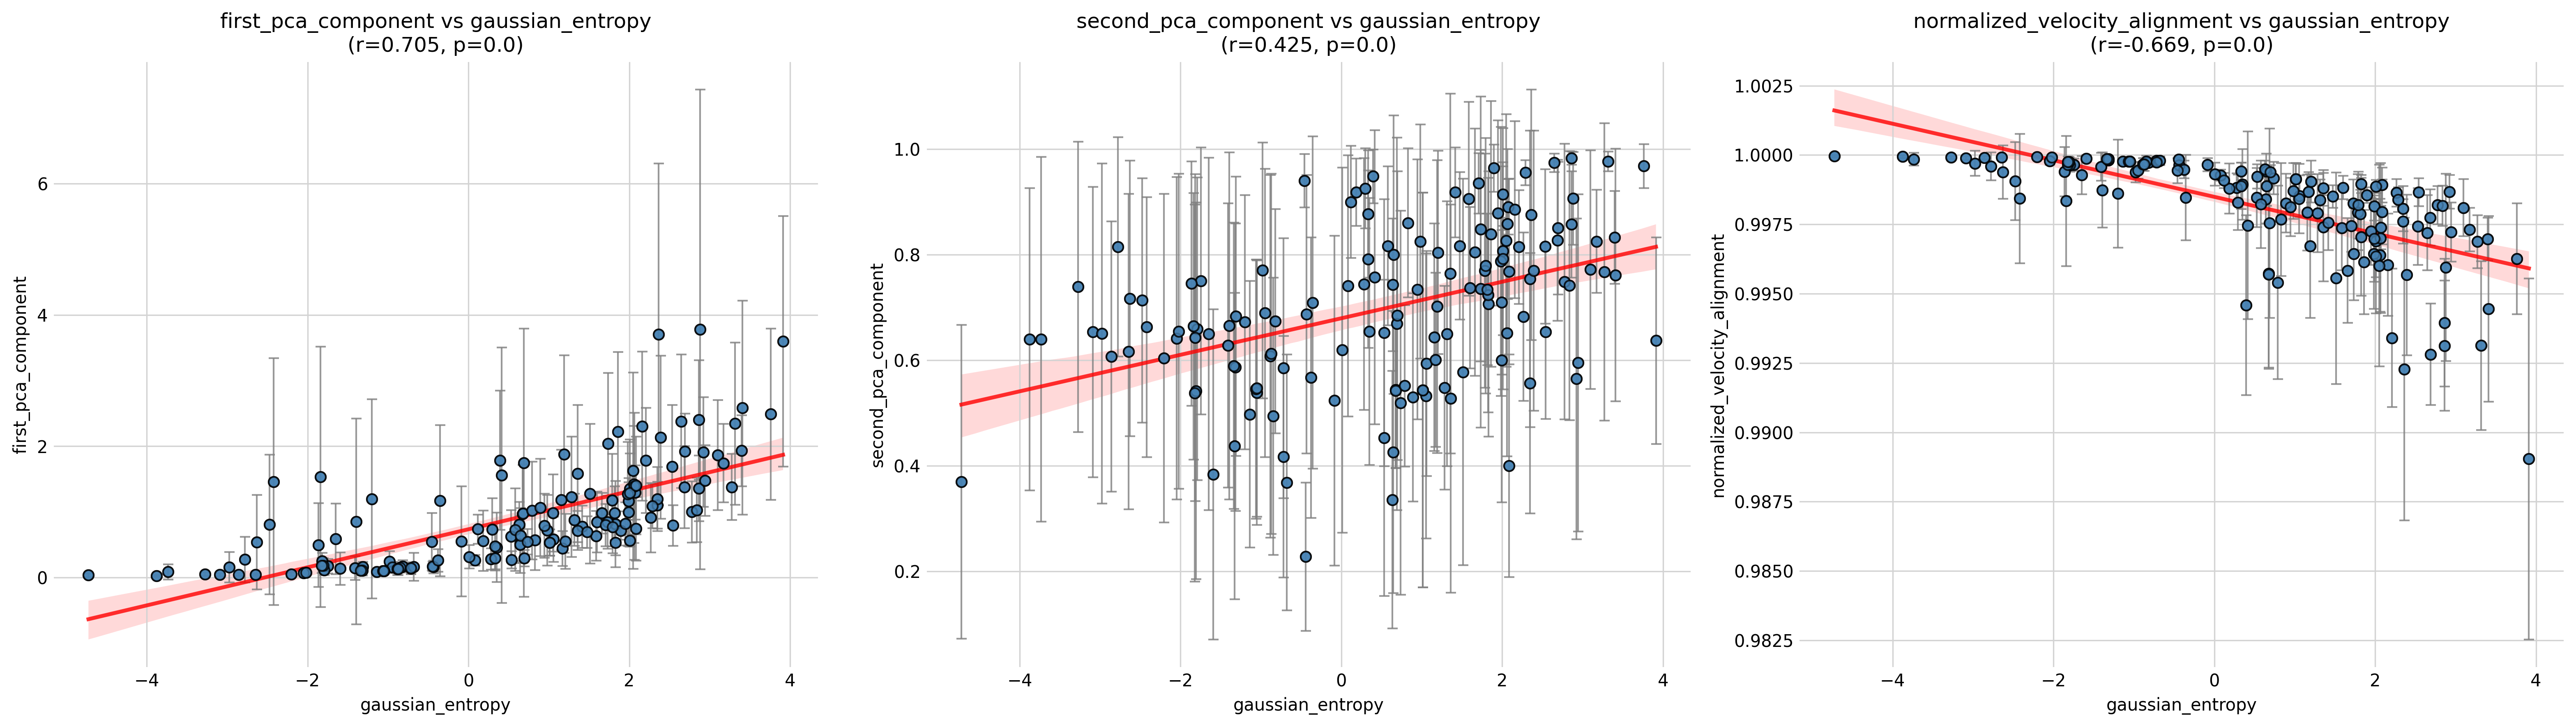

In [211]:
show_correlations(df, 'gaussian_entropy', ['first_pca_component', 'second_pca_component', 'normalized_velocity_alignment'])

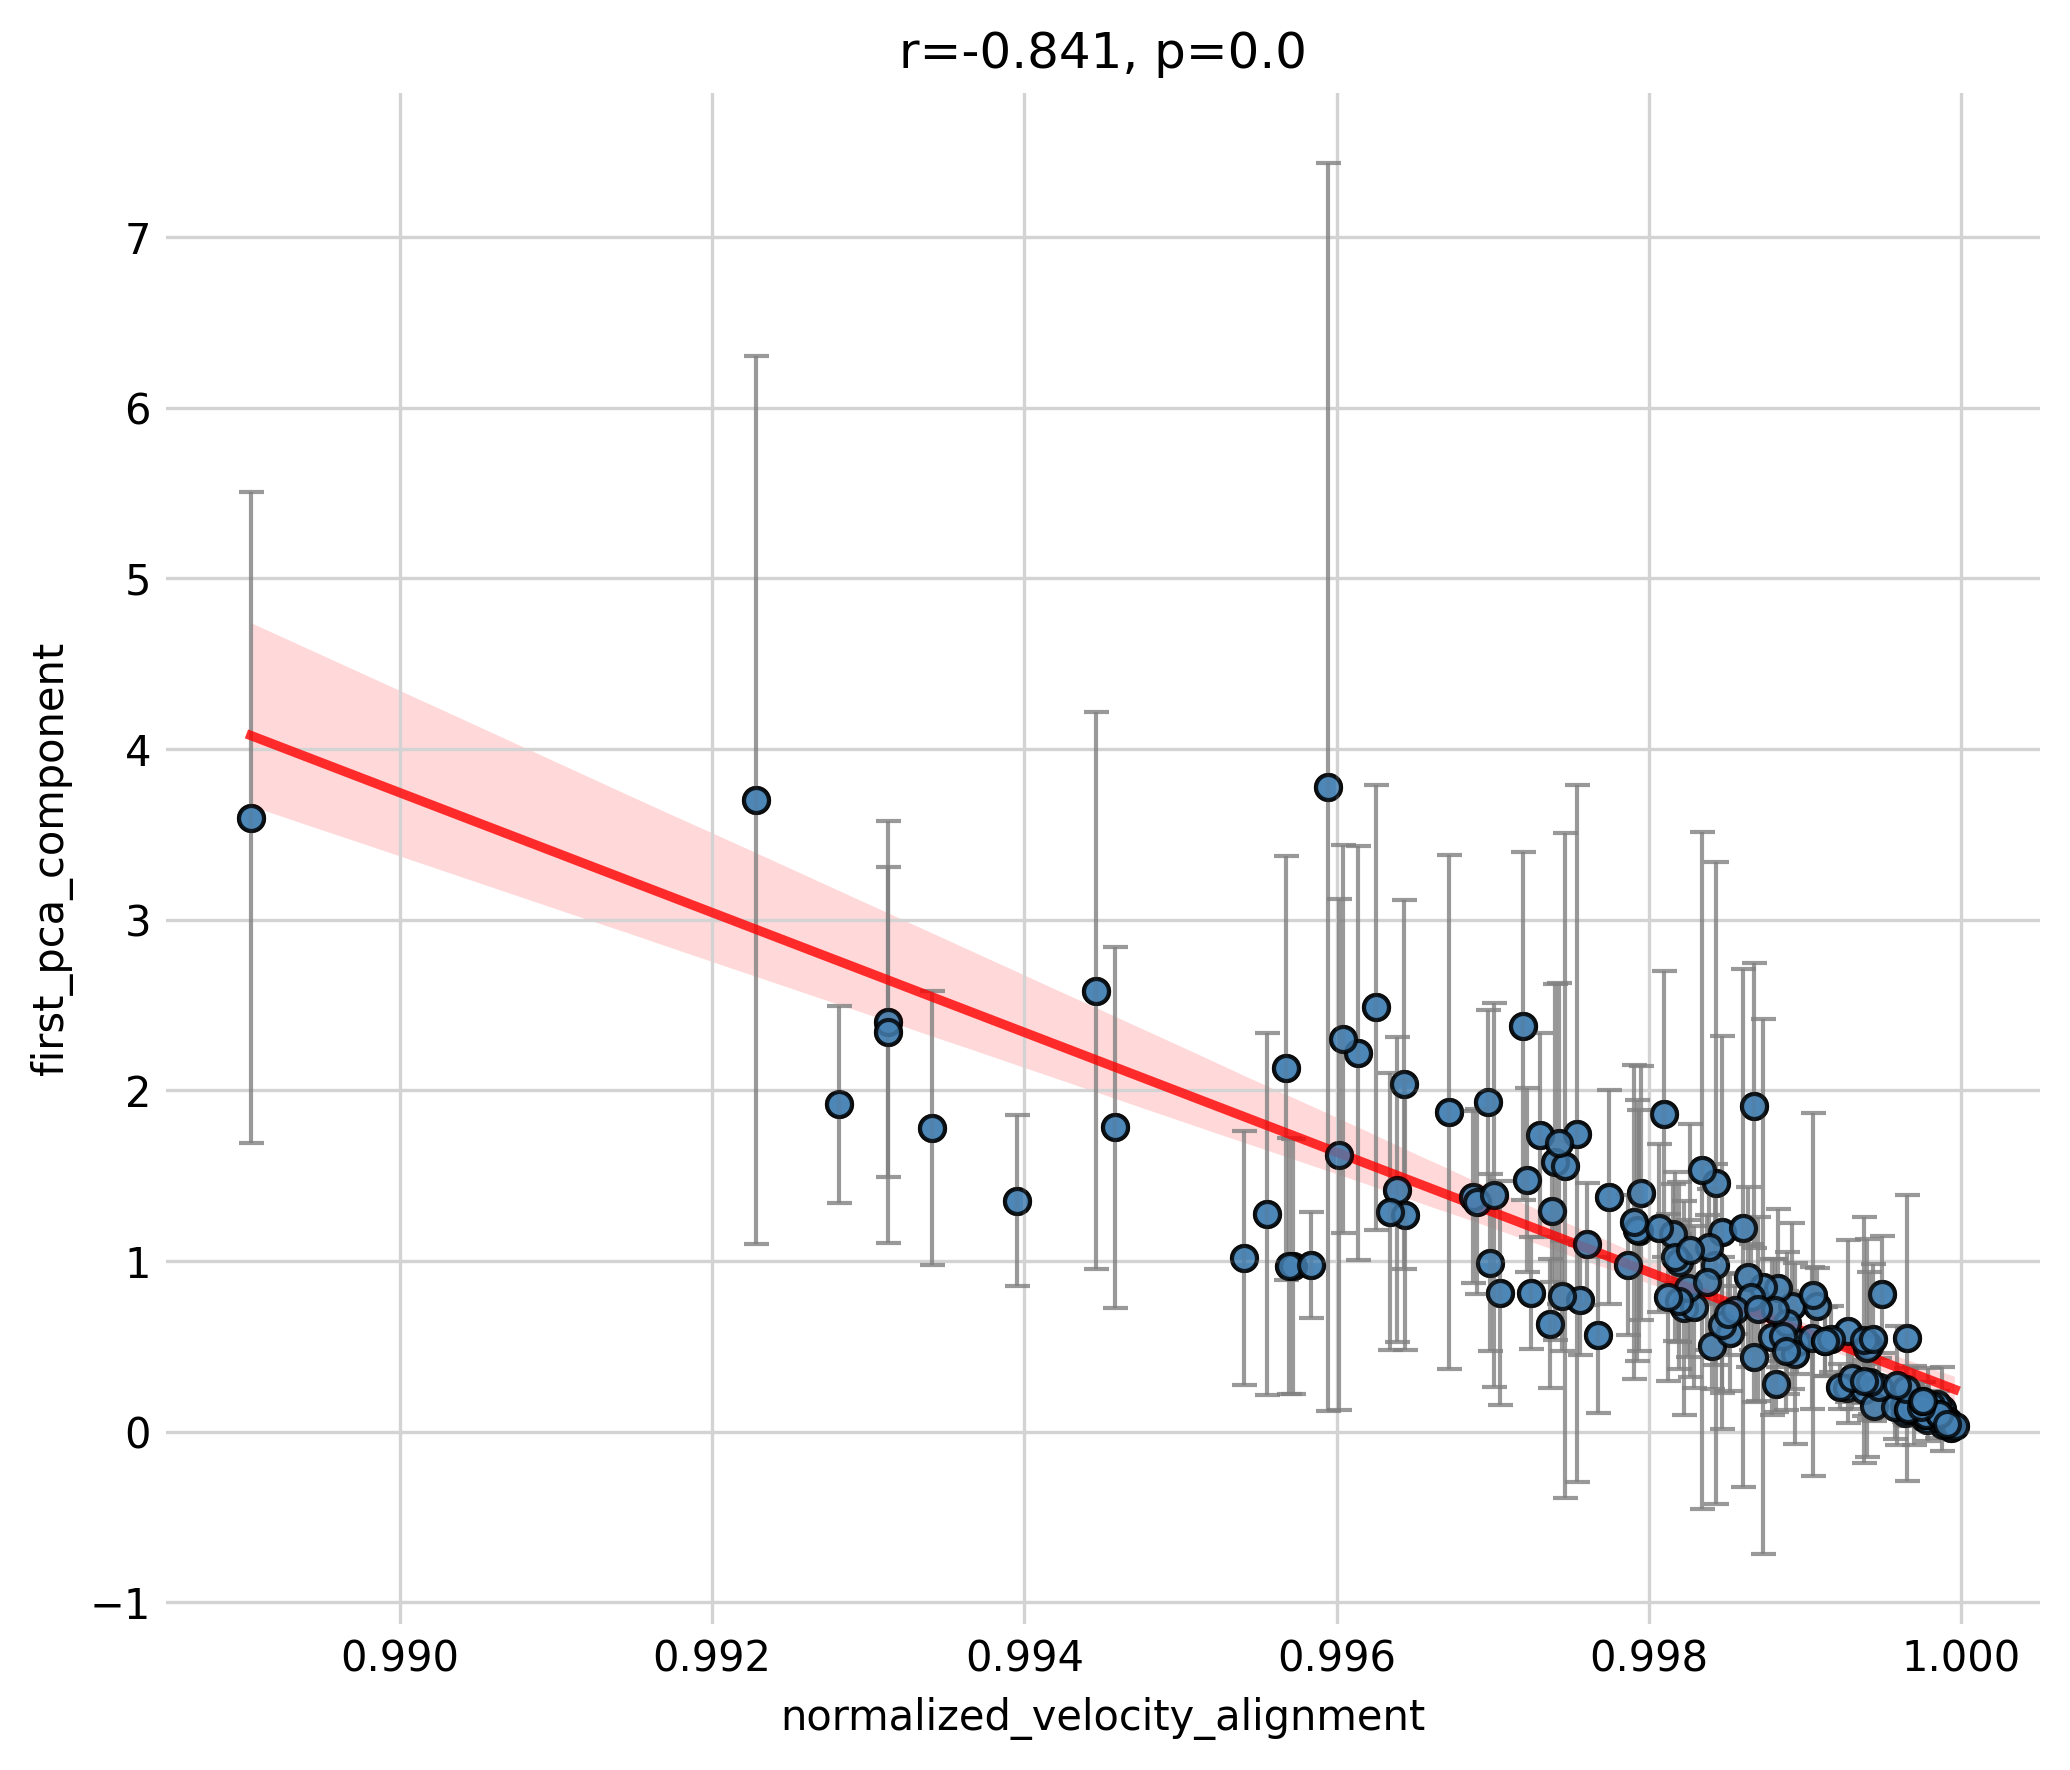

In [212]:
show_correlation(df, 'normalized_velocity_alignment', 'first_pca_component')

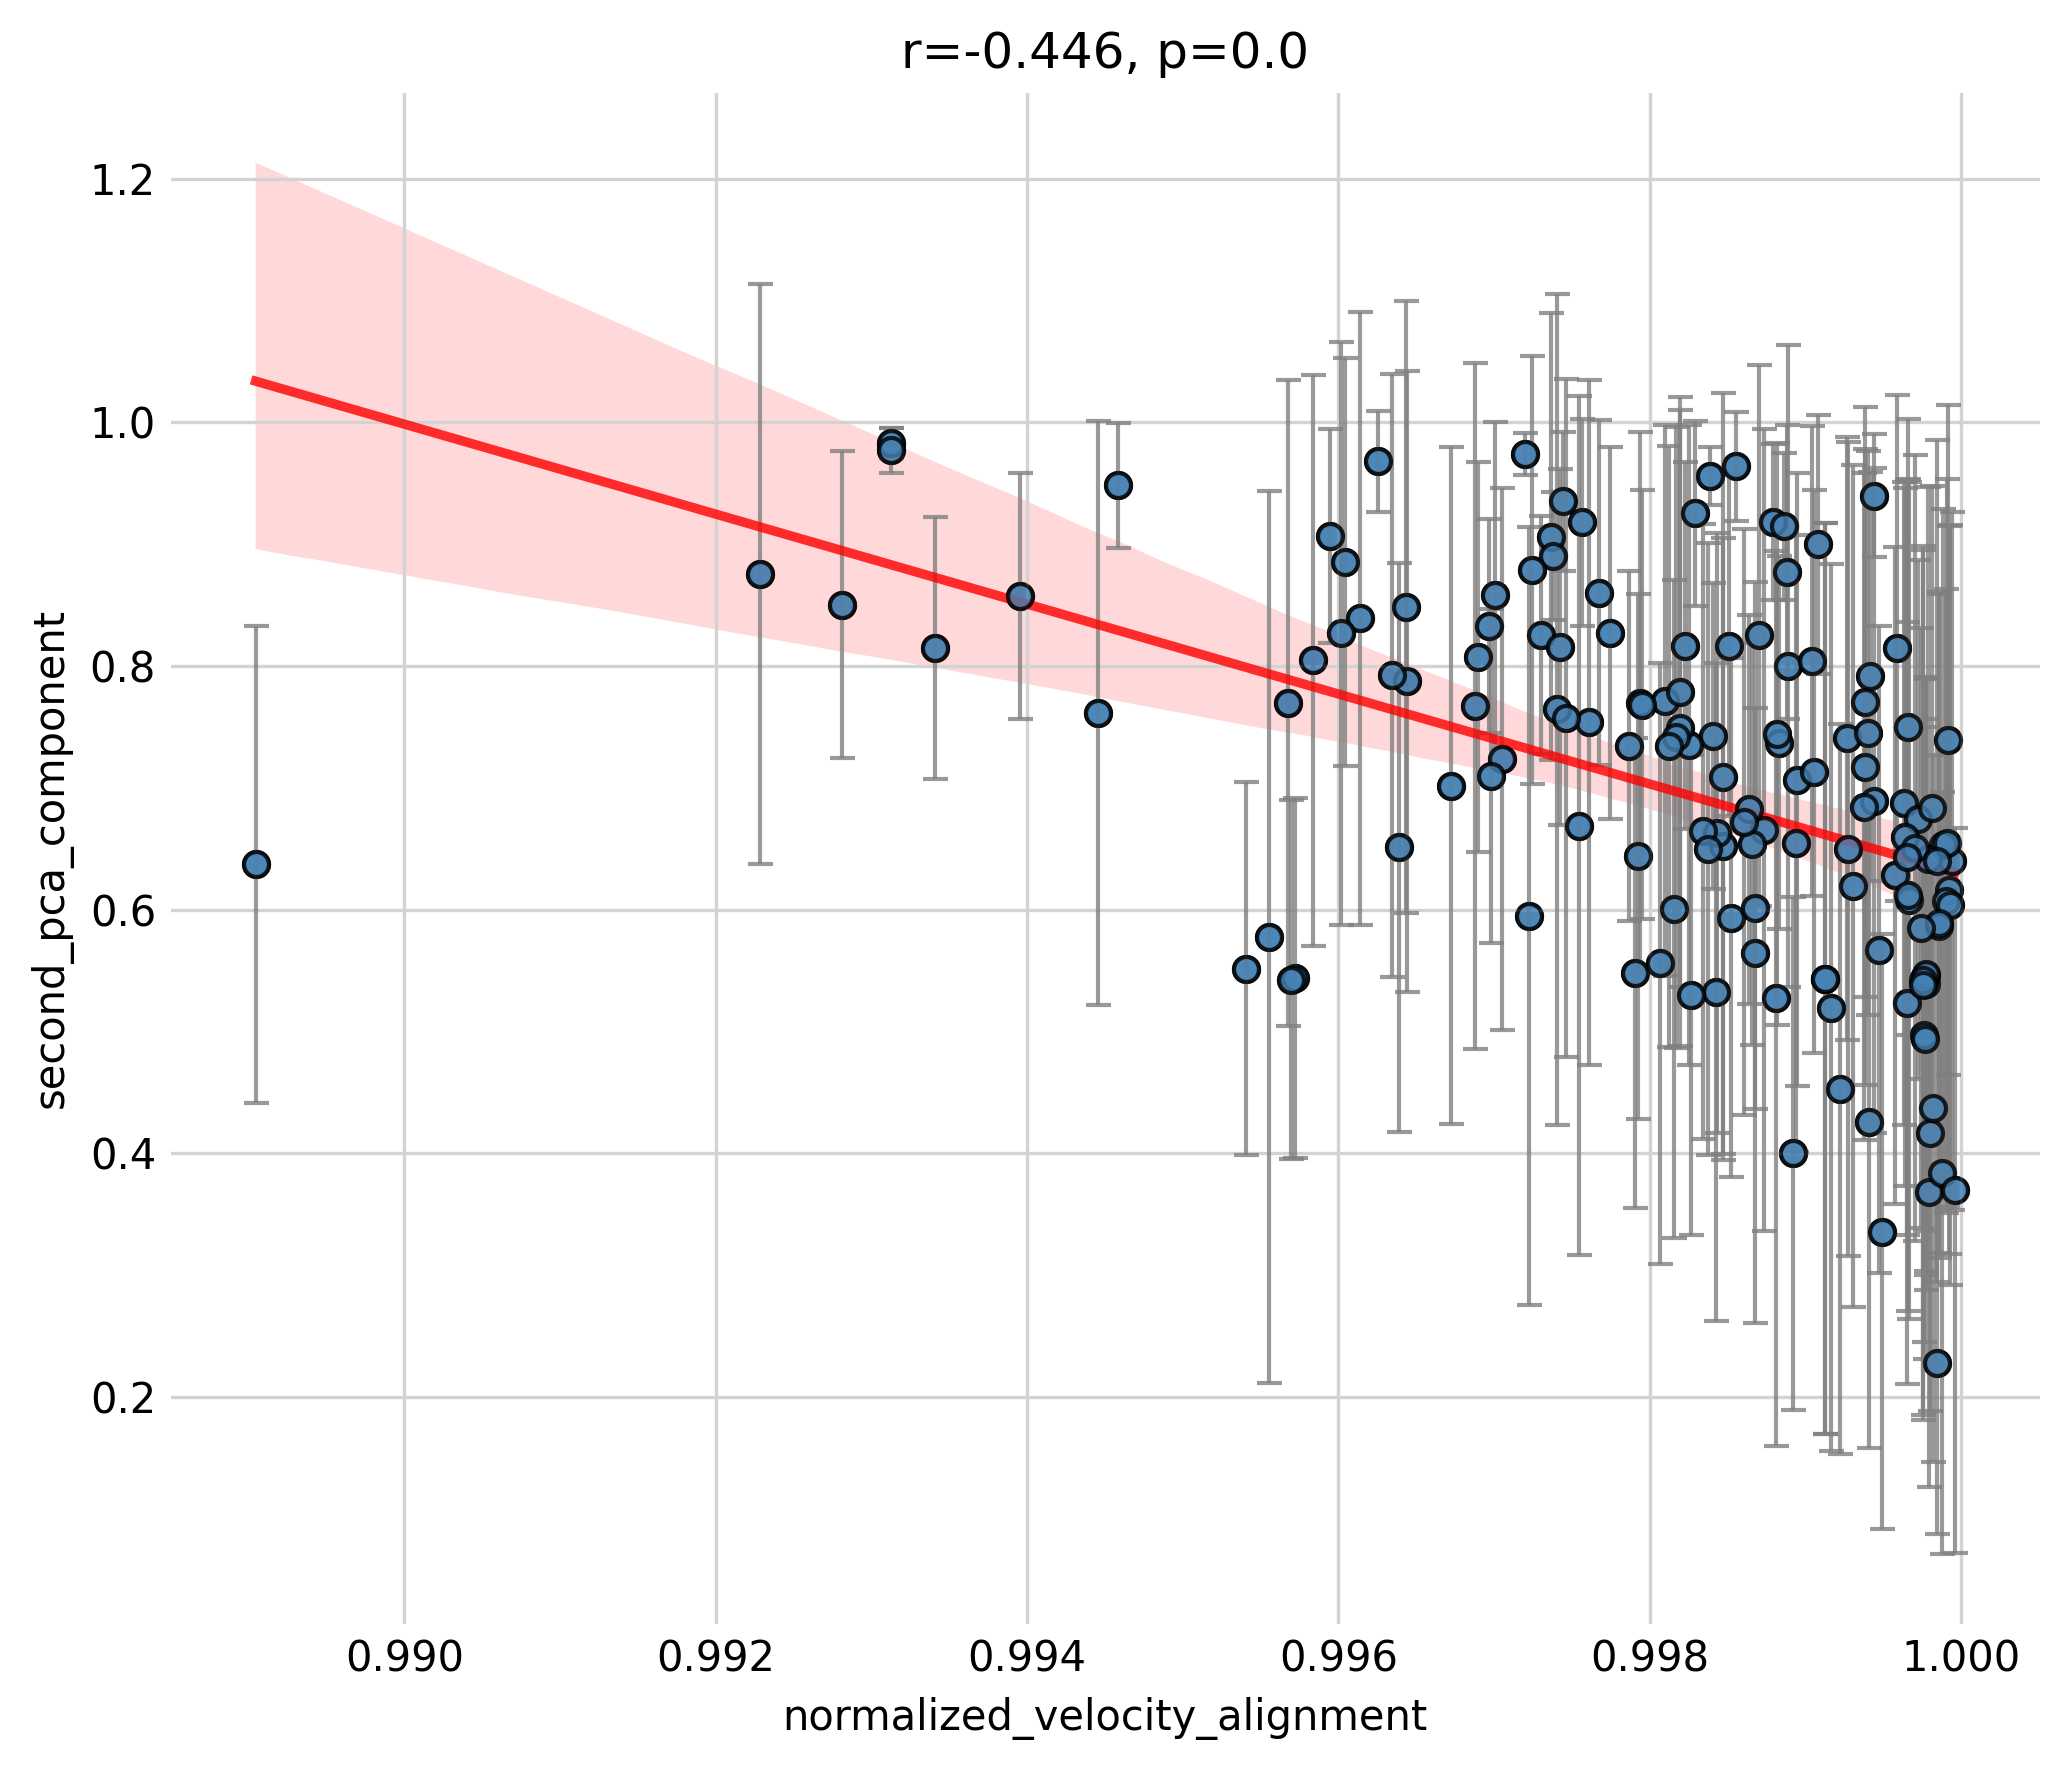

In [213]:
show_correlation(df, 'normalized_velocity_alignment', 'second_pca_component')